# Session 13 — 20M LLM × 50M Tokens × Reversibility

Three runs on **allenai/peS2o**:

1. standard ~20M causal LLM, fixed batch;
2. reversible **midpoint/leapfrog**, same fixed batch;
3. reversible midpoint/leapfrog, maximum safe batch discovered on the allocated Colab GPU.

Why peS2o?
- Chose a simple, digestible size dataset to make it easy to start off with
- it is a high-quality corpus of scientific papers, making it suitable real-world pretraining data for a small language-model experiment like this one

Tokenizer
- An 8,192-vocabulary WordPiece tokenizer trained on a medium peS2o sample is used, with FlashTokenizer (BertTokenizerFlash) for fast tokenization during dataset preparation.

Session 13 recurrence:

\[
p^{\ell+1}=p^{\ell-1}+2h\,f_{\theta_\ell}(p^\ell),\quad
p^{\ell-1}=p^{\ell+1}-2h\,f_{\theta_\ell}(p^\ell)
\]

Colab:
Use **Runtime → Change runtime type → GPU**. Set `RUN_FULL=False` for a smoke test, then `True` for GPU run.

In [1]:
!pip -q install -U "datasets<3.0" "tokenizers>=0.20" "transformers>=4.45" "flash-tokenizer>=0.1"

In [2]:
import gc, json, math, random, time, platform
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from tokenizers import BertWordPieceTokenizer
from transformers import BertTokenizerFast
from flash_tokenizer import BertTokenizerFlash

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda": torch.cuda.manual_seed_all(SEED)

RUN_FULL = True
TARGET_TOKENS = 50_000_000 if RUN_FULL else 200_000
SEQ_LEN = 512
FIXED_BATCH = 8
MAX_BATCH_CAP = 128
BATCH_SAFETY = 0.95

VOCAB_SIZE = 8192
TOKENIZER_CORPUS_CHARS = 64_000_000 if RUN_FULL else 2_000_000
TRAIN_CACHE_TOKENS = 55_000_000 if RUN_FULL else 500_000
VAL_CACHE_TOKENS = 2_000_000 if RUN_FULL else 100_000

REV_STEP_H = 0.25
D_MODEL, N_LAYERS, N_HEADS, FF_DIM = 384, 12, 6, 1024

WORK = Path("/content/s13_reversibility")
WORK.mkdir(parents=True, exist_ok=True)

if DEVICE.type == "cuda":
    major, minor = torch.cuda.get_device_capability()
    GPU_NAME = torch.cuda.get_device_name(0)
    AMP_DTYPE = torch.bfloat16 if major >= 8 else torch.float16
else:
    GPU_NAME = platform.processor() or platform.machine()
    AMP_DTYPE = torch.float32

print("device:", DEVICE)
print("hardware:", GPU_NAME)
print("AMP:", AMP_DTYPE)
print("target tokens/run:", f"{TARGET_TOKENS:,}")

device: cuda
hardware: Tesla T4
AMP: torch.float16
target tokens/run: 50,000,000


## Tokenizer: medium peS2o corpus + FlashTokenizer

FlashTokenizer is used for the **encoding path**. Its public API loads a WordPiece/BERT vocabulary rather than training a vocabulary from raw text. Therefore the notebook trains an 8,192-entry WordPiece vocabulary on a ~64 MB peS2o sample with `tokenizers`, saves it in BERT format, then loads and uses that exact vocabulary with `BertTokenizerFlash`.

The notebook verifies FlashTokenizer IDs against `BertTokenizerFast` before building the training cache.

In [8]:
import shutil
from transformers import BertTokenizerFast

TOK_DIR = WORK / "pes2o_wordpiece_8192"
CORPUS_TXT = WORK / "tokenizer_corpus.txt"

def build_tokenizer_corpus():
    if CORPUS_TXT.exists() and CORPUS_TXT.stat().st_size >= min(TOKENIZER_CORPUS_CHARS, 1_000_000):
        return
    ds = load_dataset("allenai/peS2o", "v2", split="train", streaming=True, trust_remote_code=True)
    written = docs = 0
    with CORPUS_TXT.open("w", encoding="utf-8") as f:
        for ex in ds:
            txt = (ex.get("text") or "").strip()
            if not txt: continue
            n = TOKENIZER_CORPUS_CHARS - written
            piece = txt[:n]
            f.write(piece + "\n\n")
            written += len(piece) + 2; docs += 1
            if written >= TOKENIZER_CORPUS_CHARS: break
    print(f"tokenizer corpus: {written/1e6:.1f}M chars, {docs:,} docs")

def train_tokenizer():
    if (TOK_DIR / "vocab.txt").exists() and (TOK_DIR / "tokenizer.json").exists():
        try:
            if len(BertTokenizerFast.from_pretrained(str(TOK_DIR))) >= VOCAB_SIZE:
                return
        except Exception:
            pass
        shutil.rmtree(TOK_DIR)

    TOK_DIR.mkdir(parents=True, exist_ok=True)
    wp = BertWordPieceTokenizer(lowercase=False, strip_accents=False)
    wp.train(
        files=[str(CORPUS_TXT)], vocab_size=VOCAB_SIZE, min_frequency=2,
        special_tokens=["[PAD]","[UNK]","[CLS]","[SEP]","[MASK]"]
    )
    wp.save_model(str(TOK_DIR))
    wp.save(str(TOK_DIR / "tokenizer.json"))

build_tokenizer_corpus()
train_tokenizer()

hf_tok = BertTokenizerFast.from_pretrained(str(TOK_DIR))
flash_tok = BertTokenizerFlash(str(TOK_DIR / "vocab.txt"))
PAD_ID, CLS_ID, EOS_ID = hf_tok.pad_token_id, hf_tok.cls_token_id, hf_tok.sep_token_id
ACTUAL_VOCAB = len(hf_tok)

for text in [
    "Reversible networks reconstruct activations.",
    "Scientific papers contain equations and citations."
]:
    a = hf_tok(text, add_special_tokens=True, max_length=512, padding="max_length").input_ids
    b = flash_tok(text, max_length=512).input_ids[0]
    print(text, "\n", a[:20], "\n", b[:20])
    assert a == b
print("✓ FlashTokenizer matches reference tokenizer; vocab =", ACTUAL_VOCAB)

Reversible networks reconstruct activations. 
 [2, 6231, 2082, 3456, 4637, 1813, 3773, 1015, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] 
 [2, 6231, 2082, 3456, 4637, 1813, 3773, 1015, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Scientific papers contain equations and citations. 
 [2, 4792, 7543, 6184, 5406, 1492, 71, 2982, 1015, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0] 
 [2, 4792, 7543, 6184, 5406, 1492, 71, 2982, 1015, 18, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0]
✓ FlashTokenizer matches reference tokenizer; vocab = 8192


## Token cache and target correctness

Documents are concatenated with `[SEP]` as EOS. Every sample uses a one-token target shift. The target immediately following EOS is masked, so the model is not trained across unrelated paper boundaries.

In [9]:
TRAIN_BIN = WORK/"pes2o_train.uint16"
VAL_BIN = WORK/"pes2o_validation.uint16"

def encode_doc(text, max_length=8192):
    ids = flash_tok(text, max_length=max_length).input_ids[0]
    if ids and ids[0] == CLS_ID: ids = ids[1:]
    if ids and ids[-1] == EOS_ID: ids = ids[:-1]
    return ids

def make_cache(split, target, path):
    if path.exists() and path.stat().st_size//2 >= target: return
    ds = load_dataset("allenai/peS2o", "v2", split=split, streaming=True)
    total = docs = 0
    with path.open("wb") as f:
        for ex in ds:
            txt = (ex.get("text") or "").strip()
            if not txt: continue
            ids = encode_doc(txt)
            if not ids: continue
            arr = np.asarray(ids + [EOS_ID], dtype=np.uint16)
            if total + len(arr) > target: arr = arr[:target-total]
            arr.tofile(f)
            total += len(arr); docs += 1
            if docs % 1000 == 0:
                print(f"\r{split}: {total/1e6:.2f}M/{target/1e6:.2f}M", end="")
            if total >= target: break
    print(f"\n{split}: {total:,} tokens from {docs:,} docs")

make_cache("train", TRAIN_CACHE_TOKENS, TRAIN_BIN)
make_cache("validation", VAL_CACHE_TOKENS, VAL_BIN)
train_tokens = np.memmap(TRAIN_BIN, dtype=np.uint16, mode="r")
val_tokens = np.memmap(VAL_BIN, dtype=np.uint16, mode="r")

def sample_batch(arr, batch, seq_len=SEQ_LEN):
    hi = len(arr) - seq_len - 1
    starts = np.random.randint(0, hi, size=batch)
    x = np.stack([arr[s:s+seq_len] for s in starts]).astype(np.int64)
    y = np.stack([arr[s+1:s+seq_len+1] for s in starts]).astype(np.int64)
    x = torch.from_numpy(x).to(DEVICE, non_blocking=True)
    y = torch.from_numpy(y).to(DEVICE, non_blocking=True)
    valid = x.ne(EOS_ID)
    return x, y, valid

xd, yd, vd = sample_batch(train_tokens, 2)
print("x/y/mask:", xd.shape, yd.shape, vd.shape)
print("valid fraction:", vd.float().mean().item())

train: 49.15M/55.00M
train: 55,000,000 tokens from 6,714 docs

validation: 2,000,000 tokens from 245 docs
x/y/mask: torch.Size([2, 512]) torch.Size([2, 512]) torch.Size([2, 512])
valid fraction: 1.0


## ~20M model

Both variants use identical transformer blocks and tied input/output embeddings. Dropout is **zero** because reversible reconstruction requires deterministic block evaluation.

In [10]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__(); self.weight=nn.Parameter(torch.ones(d)); self.eps=eps
    def forward(self,x):
        return self.weight*x*torch.rsqrt(x.pow(2).mean(-1,keepdim=True)+self.eps)

class CausalAttention(nn.Module):
    def __init__(self,d,h):
        super().__init__(); assert d%h==0
        self.h=h; self.hd=d//h
        self.qkv=nn.Linear(d,3*d,bias=False); self.out=nn.Linear(d,d,bias=False)
    def forward(self,x):
        B,T,C=x.shape
        q,k,v=self.qkv(x).chunk(3,-1)
        def heads(z): return z.view(B,T,self.h,self.hd).transpose(1,2)
        q,k,v=heads(q),heads(k),heads(v)
        y=F.scaled_dot_product_attention(q,k,v,is_causal=True,dropout_p=0.0)
        return self.out(y.transpose(1,2).contiguous().view(B,T,C))

class TransformerDelta(nn.Module):
    def __init__(self,d,h,ff):
        super().__init__()
        self.n1=RMSNorm(d); self.attn=CausalAttention(d,h)
        self.n2=RMSNorm(d); self.fc1=nn.Linear(d,ff,bias=False); self.fc2=nn.Linear(ff,d,bias=False)
    def forward(self,x):
        a=self.attn(self.n1(x))
        z=x+a
        m=self.fc2(F.silu(self.fc1(self.n2(z))))
        return a+m

class StandardStack(nn.Module):
    def __init__(self,blocks):
        super().__init__(); self.blocks=blocks
    def forward(self,x):
        for b in self.blocks: x=x+b(x)
        return x

def ac():
    return torch.autocast("cuda",dtype=AMP_DTYPE) if DEVICE.type=="cuda" else nullcontext()

## Exact midpoint reconstruction backward

The custom autograd function keeps only the final two stack states. During backward it reconstructs each previous state using the inverse recurrence and re-evaluates that block to obtain local gradients.

A single Euler **starter** creates \(p^1\) from \(p^0\); the reversible depth rule being evaluated is still midpoint/leapfrog. The lesson's separate Lightning LM note about blend coefficient 0.5 is not inserted into this simplified recurrence because that coefficient is not present in the displayed midpoint equation.

In [11]:
class RevMidFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx,x,blocks,h,amp_dtype,*params):
        ctx.blocks=blocks; ctx.h=float(h); ctx.amp_dtype=amp_dtype
        ctx.counts=[len(list(b.parameters())) for b in blocks]
        with torch.no_grad(), ac():
            p0=x
            p1=p0+h*blocks[0](p0)
            prev,curr=p0,p1
            for i in range(1,len(blocks)):
                prev,curr=curr,prev+2*h*blocks[i](curr)
        ctx.save_for_backward(prev.detach(),curr.detach())
        return curr

    @staticmethod
    def backward(ctx,gout):
        blocks,h=ctx.blocks,ctx.h
        pc,pn=ctx.saved_tensors
        gc=torch.zeros_like(pc); gn=gout
        pgrads=[None]*sum(ctx.counts)
        offsets=[]; o=0
        for n in ctx.counts: offsets.append((o,o+n)); o+=n

        for i in range(len(blocks)-1,0,-1):
            z=pc.detach().requires_grad_(True)
            plist=list(blocks[i].parameters())
            with torch.enable_grad(), ac(): f=blocks[i](z)
            loc=torch.autograd.grad(f,[z]+plist,grad_outputs=2*h*gn,allow_unused=True)
            a,b=offsets[i]
            for j,g in enumerate(loc[1:]): pgrads[a+j]=g
            with torch.no_grad():
                pp=pn-2*h*f.detach()
                total_gc=gc+loc[0]
                gp=gn
                pn,pc=pc,pp; gn,gc=total_gc,gp

        z=pc.detach().requires_grad_(True)
        plist=list(blocks[0].parameters())
        with torch.enable_grad(), ac(): f0=blocks[0](z)
        loc=torch.autograd.grad(f0,[z]+plist,grad_outputs=h*gn,allow_unused=True)
        a,b=offsets[0]
        for j,g in enumerate(loc[1:]): pgrads[a+j]=g
        gx=gc+gn+loc[0]
        return (gx,None,None,None,*pgrads)

class ReversibleMidpointStack(nn.Module):
    def __init__(self,blocks,h=0.25):
        super().__init__(); self.blocks=blocks; self.h=h
    def forward(self,x):
        return RevMidFn.apply(x,self.blocks,self.h,AMP_DTYPE,*tuple(self.parameters()))

class TinyLM(nn.Module):
    def __init__(self,reversible=False):
        super().__init__()
        self.tok=nn.Embedding(ACTUAL_VOCAB,D_MODEL)
        self.pos=nn.Embedding(SEQ_LEN,D_MODEL)
        blocks=nn.ModuleList([TransformerDelta(D_MODEL,N_HEADS,FF_DIM) for _ in range(N_LAYERS)])
        self.stack=ReversibleMidpointStack(blocks,REV_STEP_H) if reversible else StandardStack(blocks)
        self.norm=RMSNorm(D_MODEL)
        self.head=nn.Linear(D_MODEL,ACTUAL_VOCAB,bias=False)
        self.head.weight=self.tok.weight
    def forward(self,t):
        pos=torch.arange(t.size(1),device=t.device)
        return self.norm(self.stack(self.tok(t)+self.pos(pos)[None]))
    def logits(self,h): return self.head(h)

P0=sum(p.numel() for p in TinyLM(False).parameters())
P1=sum(p.numel() for p in TinyLM(True).parameters())
print("params:",f"{P0:,} ({P0/1e6:.3f}M)")
assert P0==P1 and 19_000_000<=P0<=21_000_000

params: 19,867,008 (19.867M)


## Gradient audit before long training

The custom reconstruction backward is compared with normal autograd on the same three-block midpoint recurrence. The 50M-token runs should not begin unless output, input-gradient, and parameter-gradient errors are small.

In [12]:
def naive_mid(stack,x):
    bs,h=stack.blocks,stack.h
    p0=x; p1=p0+h*bs[0](p0); prev,curr=p0,p1
    for i in range(1,len(bs)): prev,curr=curr,prev+2*h*bs[i](curr)
    return curr

def audit_rev():
    torch.manual_seed(123)
    holder=TinyLM(True).to(DEVICE)
    bs=nn.ModuleList(list(holder.stack.blocks[:3]))
    rev=ReversibleMidpointStack(bs,REV_STEP_H).to(DEVICE)
    x=torch.randn(1,16,D_MODEL,device=DEVICE,requires_grad=True)
    with ac(): y0=naive_mid(rev,x); l0=y0.float().square().mean()
    l0.backward()
    gx=x.grad.detach().clone(); gps=[p.grad.detach().clone() for p in rev.parameters()]
    for p in rev.parameters(): p.grad=None
    x1=x.detach().clone().requires_grad_(True)
    with ac(): y1=rev(x1); l1=y1.float().square().mean()
    l1.backward()
    oe=(y1.detach()-y0.detach()).abs().max().item()
    xe=(x1.grad-gx).abs().max().item()
    pe=max((p.grad-g).abs().max().item() for p,g in zip(rev.parameters(),gps))
    print("output/input-grad/param-grad max errors:",oe,xe,pe)
    assert oe<5e-3 and xe<5e-2 and pe<5e-2
    del holder,bs,rev,x,x1,y0,y1
    gc.collect()
    if DEVICE.type=="cuda": torch.cuda.empty_cache()
    return {"output_error":oe,"input_grad_error":xe,"param_grad_error":pe}

REV_AUDIT=audit_rev()
print("✓ reversible backward audit passed")

output/input-grad/param-grad max errors: 0.0 3.0617957236245275e-07 1.0132789611816406e-06
✓ reversible backward audit passed


## Loss, schedule, and OOM-safe batch search

The loss is token-normalized and masks cross-document targets. The reversible maximum-batch probe executes a real forward/backward/AdamW step, then uses exponential search + binary search. A 5% safety margin is used for the long run.

In [13]:
def lm_loss(model,x,y,valid):
    logits=model.logits(model(x)); B,T,V=logits.shape
    z=F.cross_entropy(logits.reshape(-1,V),y.reshape(-1),reduction="none").view(B,T)
    w=valid.to(z.dtype)
    return (z*w).sum()/w.sum().clamp_min(1)

def lr_at(step,total,hi=3e-4,lo=3e-5):
    warm=min(500,max(20,int(.05*total)))
    if step<warm: return hi*(step+1)/warm
    r=min(1.,(step-warm)/max(1,total-warm))
    return lo+.5*(hi-lo)*(1+math.cos(math.pi*r))

@torch.no_grad()
def evaluate(model,batches=20,batch=FIXED_BATCH):
    model.eval(); out=[]
    for _ in range(batches):
        x,y,v=sample_batch(val_tokens,batch)
        with ac(): out.append(float(lm_loss(model,x,y,v)))
    model.train()
    return float(np.mean(out))

def clear_cuda():
    gc.collect()
    if DEVICE.type=="cuda":
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

def probe(batch):
    clear_cuda(); torch.manual_seed(SEED)
    m=TinyLM(True).to(DEVICE)
    o=torch.optim.AdamW(m.parameters(),lr=1e-4,betas=(.9,.95),weight_decay=.1)
    sc=torch.amp.GradScaler("cuda",enabled=(DEVICE.type=="cuda" and AMP_DTYPE==torch.float16))
    x,y,v=sample_batch(train_tokens,batch)
    try:
        with ac(): loss=lm_loss(m,x,y,v)
        sc.scale(loss).backward(); sc.unscale_(o)
        torch.nn.utils.clip_grad_norm_(m.parameters(),1.)
        sc.step(o); sc.update()
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        peak=torch.cuda.max_memory_allocated()/2**30 if DEVICE.type=="cuda" else float("nan")
        ok=True
    except torch.cuda.OutOfMemoryError:
        ok=False; peak=float("inf")
    del m,o,sc,x,y,v
    clear_cuda()
    return ok,peak

def find_max_batch():
    if DEVICE.type!="cuda": return FIXED_BATCH,[]
    hist=[]; low=0; high=None; b=FIXED_BATCH
    while b<=MAX_BATCH_CAP:
        ok,p=probe(b); hist.append((b,ok,p)); print("probe",b,ok,p)
        if ok: low=b; b*=2
        else: high=b; break
    if high is None: high=MAX_BATCH_CAP+1
    lo,hi=low+1,min(high-1,MAX_BATCH_CAP)
    while lo<=hi:
        mid=(lo+hi)//2; ok,p=probe(mid); hist.append((mid,ok,p)); print("probe",mid,ok,p)
        if ok: low=mid; lo=mid+1
        else: hi=mid-1
    safe=max(FIXED_BATCH,int(low*BATCH_SAFETY))
    print("largest passing:",low,"safe long-run batch:",safe)
    return safe,hist

REV_MAX_BATCH,BATCH_PROBE=find_max_batch()

probe 8 True 0.4294142723083496
probe 16 True 0.7625174522399902
probe 32 True 1.4287238121032715
probe 64 True 2.761136531829834
probe 128 True 5.425961971282959
largest passing: 128 safe long-run batch: 121


## Three 50M-token training experiments

In [14]:
def train_run(name,reversible,batch,target=TARGET_TOKENS):
    clear_cuda(); torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    m=TinyLM(reversible).to(DEVICE)
    o=torch.optim.AdamW(m.parameters(),lr=3e-4,betas=(.9,.95),weight_decay=.1)
    sc=torch.amp.GradScaler("cuda",enabled=(DEVICE.type=="cuda" and AMP_DTYPE==torch.float16))
    tps=batch*SEQ_LEN; steps=math.ceil(target/tps)
    if DEVICE.type=="cuda":
        torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    losses=[]; norms=[]; seen=0; t0=time.perf_counter(); lt=t0; ls=0
    m.train()
    for step in range(steps):
        lr=lr_at(step,steps)
        for pg in o.param_groups: pg["lr"]=lr
        x,y,v=sample_batch(train_tokens,batch); o.zero_grad(set_to_none=True)
        with ac(): loss=lm_loss(m,x,y,v)
        sc.scale(loss).backward(); sc.unscale_(o)
        gn=torch.nn.utils.clip_grad_norm_(m.parameters(),1.)
        sc.step(o); sc.update()
        seen+=tps; losses.append(float(loss)); norms.append(float(gn))
        if step%50==0 or step==steps-1:
            if DEVICE.type=="cuda": torch.cuda.synchronize()
            now=time.perf_counter(); local=(seen-ls)/max(now-lt,1e-9)
            peak=torch.cuda.max_memory_allocated()/2**30 if DEVICE.type=="cuda" else float("nan")
            print(f"{name:22s} {step+1:5d}/{steps} {seen/1e6:7.2f}M loss={loss.item():.4f} grad={float(gn):.3f} tok/s={local:,.0f} peak={peak:.2f}GiB")
            lt,ls=now,seen
    if DEVICE.type=="cuda": torch.cuda.synchronize()
    wall=time.perf_counter()-t0
    peak_a=torch.cuda.max_memory_allocated()/2**30 if DEVICE.type=="cuda" else float("nan")
    peak_r=torch.cuda.max_memory_reserved()/2**30 if DEVICE.type=="cuda" else float("nan")
    val=evaluate(m,20 if RUN_FULL else 3,min(batch,FIXED_BATCH))
    result={
        "name":name,"variant":"midpoint/leapfrog" if reversible else "standard residual",
        "batch_size":batch,"tokens_seen":seen,"steps":steps,"parameters":P0,
        "final_train_loss_100step_mean":float(np.mean(losses[-min(100,len(losses)):])),
        "final_validation_loss":val,"validation_perplexity":float(math.exp(min(20,val))),
        "tokens_per_second_overall":seen/wall,
        "peak_memory_allocated_GiB":peak_a,"peak_memory_reserved_GiB":peak_r,
        "wall_seconds":wall,"grad_norm_mean":float(np.mean(norms)),
        "grad_norm_p95":float(np.percentile(norms,95)),"loss_curve":losses
    }
    torch.save({"model":m.state_dict(),"result":{k:v for k,v in result.items() if k!="loss_curve"}},WORK/f"{name}.pt")
    del m,o,sc; clear_cuda()
    return result

RESULTS=[]
RESULTS.append(train_run("baseline_fixed",False,FIXED_BATCH))
RESULTS.append(train_run("reversible_fixed",True,FIXED_BATCH))
RESULTS.append(train_run("reversible_max_batch",True,REV_MAX_BATCH))

/tmp/ipykernel_4613/1692073919.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  seen+=tps; losses.append(float(loss)); norms.append(float(gn))


baseline_fixed             1/12208    0.00M loss=0.0000 grad=0.000 tok/s=36,657 peak=1.14GiB
baseline_fixed            51/12208    0.21M loss=0.0000 grad=0.000 tok/s=55,938 peak=1.29GiB
baseline_fixed           101/12208    0.41M loss=3.7094 grad=1.611 tok/s=56,339 peak=1.29GiB
baseline_fixed           151/12208    0.62M loss=0.0001 grad=0.006 tok/s=51,182 peak=1.29GiB
baseline_fixed           201/12208    0.82M loss=0.0004 grad=0.029 tok/s=50,135 peak=1.29GiB
baseline_fixed           251/12208    1.03M loss=0.0001 grad=0.005 tok/s=54,773 peak=1.29GiB
baseline_fixed           301/12208    1.23M loss=0.1876 grad=0.115 tok/s=54,611 peak=1.29GiB
baseline_fixed           351/12208    1.44M loss=0.0000 grad=0.000 tok/s=54,257 peak=1.29GiB
baseline_fixed           401/12208    1.64M loss=2.3186 grad=0.645 tok/s=54,872 peak=1.29GiB
baseline_fixed           451/12208    1.85M loss=0.0001 grad=0.005 tok/s=54,298 peak=1.29GiB
baseline_fixed           501/12208    2.05M loss=2.0277 grad=1.087 tok

## Measured report, plots, and README block

baseline_fixed         batch=  8 val_loss=0.2454 tok/s=51,776 peak=1.29GiB wall=16.1min
reversible_fixed       batch=  8 val_loss=0.2504 tok/s=41,396 peak=0.58GiB wall=20.1min
reversible_max_batch   batch=121 val_loss=0.2428 tok/s=50,724 peak=5.28GiB wall=16.4min


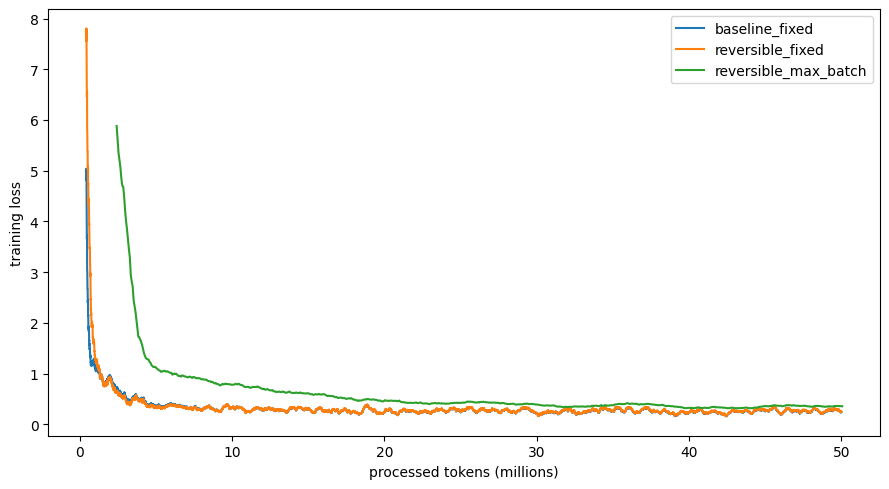

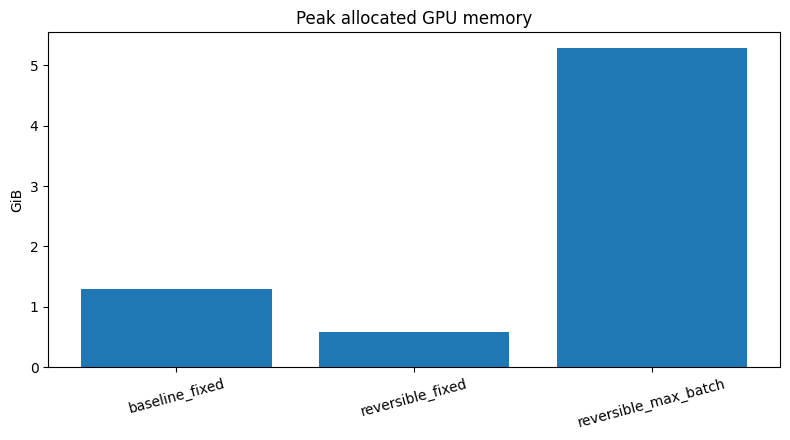

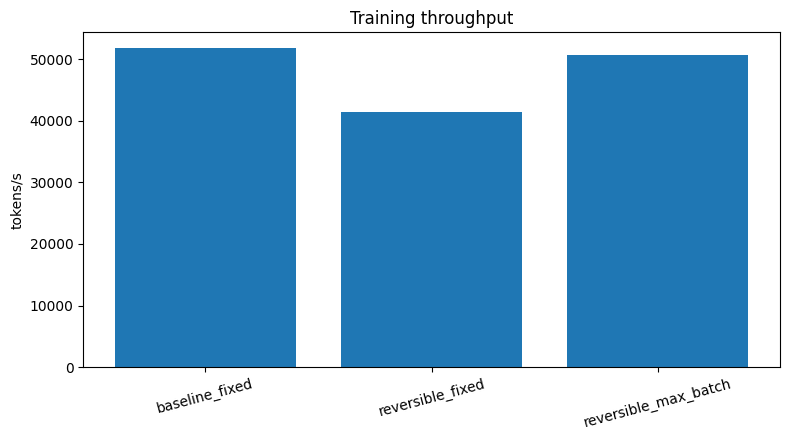

## Measured results

Hardware: **Tesla T4**  
Precision: **torch.float16**  
Parameters: **19,867,008**  
Vocabulary: **8,192**  
Reversible variant: **midpoint/leapfrog**, h=0.25  
Maximum safe reversible batch: **121**

| run | variant | batch | tokens | final val loss | token/s | peak GiB | wall min |
|---|---|---:|---:|---:|---:|---:|---:|
| baseline_fixed | standard residual | 8 | 50.004M | 0.2454 | 51,776 | 1.29 | 16.1 |
| reversible_fixed | midpoint/leapfrog | 8 | 50.004M | 0.2504 | 41,396 | 0.58 | 20.1 |
| reversible_max_batch | midpoint/leapfrog | 121 | 50.057M | 0.2428 | 50,724 | 5.28 | 16.4 |

### Reversibility numerical audit
- output max abs error: `0`
- input-gradient max abs error: `3.0618e-07`
- parameter-gradient max abs error: `1.01328e-06`


In [15]:
for r in RESULTS:
    print(f"{r['name']:22s} batch={r['batch_size']:3d} val_loss={r['final_validation_loss']:.4f} tok/s={r['tokens_per_second_overall']:,.0f} peak={r['peak_memory_allocated_GiB']:.2f}GiB wall={r['wall_seconds']/60:.1f}min")

plt.figure(figsize=(9,5))
for r in RESULTS:
    a=np.asarray(r["loss_curve"]); x=np.linspace(0,r["tokens_seen"]/1e6,len(a))
    k=min(100,max(1,len(a)//20))
    y=np.convolve(a,np.ones(k)/k,mode="valid") if k>1 else a
    xx=x[k-1:] if k>1 else x
    plt.plot(xx,y,label=r["name"])
plt.xlabel("processed tokens (millions)"); plt.ylabel("training loss"); plt.legend(); plt.tight_layout()
plt.savefig(WORK/"loss_curves.png",dpi=160); plt.show()

for field,title,file,ylabel in [
    ("peak_memory_allocated_GiB","Peak allocated GPU memory","peak_memory.png","GiB"),
    ("tokens_per_second_overall","Training throughput","throughput.png","tokens/s")
]:
    plt.figure(figsize=(8,4.5))
    plt.bar([r["name"] for r in RESULTS],[r[field] for r in RESULTS])
    plt.ylabel(ylabel); plt.xticks(rotation=15); plt.title(title); plt.tight_layout()
    plt.savefig(WORK/file,dpi=160); plt.show()

payload={"hardware":GPU_NAME,"amp_dtype":str(AMP_DTYPE),"run_full":RUN_FULL,
         "reversible_audit":REV_AUDIT,"batch_probe":BATCH_PROBE,"results":RESULTS}
(WORK/"session13_results.json").write_text(json.dumps(payload,indent=2))

rows=[]
for r in RESULTS:
    rows.append("| {} | {} | {} | {:.3f}M | {:.4f} | {:,.0f} | {:.2f} | {:.1f} |".format(
        r["name"],r["variant"],r["batch_size"],r["tokens_seen"]/1e6,r["final_validation_loss"],
        r["tokens_per_second_overall"],r["peak_memory_allocated_GiB"],r["wall_seconds"]/60))
lines=[
"## Measured results","",f"Hardware: **{GPU_NAME}**  ",f"Precision: **{AMP_DTYPE}**  ",
f"Parameters: **{P0:,}**  ",f"Vocabulary: **{ACTUAL_VOCAB:,}**  ",
f"Reversible variant: **midpoint/leapfrog**, h={REV_STEP_H}  ",
f"Maximum safe reversible batch: **{REV_MAX_BATCH}**","",
"| run | variant | batch | tokens | final val loss | token/s | peak GiB | wall min |",
"|---|---|---:|---:|---:|---:|---:|---:|",*rows,"",
"### Reversibility numerical audit",
f"- output max abs error: `{REV_AUDIT['output_error']:.6g}`",
f"- input-gradient max abs error: `{REV_AUDIT['input_grad_error']:.6g}`",
f"- parameter-gradient max abs error: `{REV_AUDIT['param_grad_error']:.6g}`",
]
(WORK/"README_RESULTS.md").write_text("\n".join(lines))
print("\n".join(lines))

In [17]:
# pasted above output in a markdown cell below

| run | variant | batch | tokens | final val loss | token/s | peak GiB | wall min |
|---|---|---:|---:|---:|---:|---:|---:|
| baseline_fixed | standard residual | 8 | 50.004M | 0.2454 | 51,776 | 1.29 | 16.1 |
| reversible_fixed | midpoint/leapfrog | 8 | 50.004M | 0.2504 | 41,396 | 0.58 | 20.1 |
| reversible_max_batch | midpoint/leapfrog | 121 | 50.057M | 0.2428 | 50,724 | 5.28 | 16.4 |


In [18]:
!zip -r archive.zip /content/s13_reversibility

  adding: content/s13_reversibility/ (stored 0%)
  adding: content/s13_reversibility/README_RESULTS.md (deflated 46%)
  adding: content/s13_reversibility/baseline_fixed.pt (deflated 7%)
  adding: content/s13_reversibility/pes2o_validation.uint16 (deflated 97%)
  adding: content/s13_reversibility/session13_results.json (deflated 67%)
  adding: content/s13_reversibility/peak_memory.png (deflated 22%)
  adding: content/s13_reversibility/tokenizer_corpus.txt (deflated 64%)
  adding: content/s13_reversibility/pes2o_wordpiece_8192/ (stored 0%)
  adding: content/s13_reversibility/pes2o_wordpiece_8192/vocab.txt (deflated 50%)
  adding: content/s13_reversibility/pes2o_wordpiece_8192/tokenizer.json (deflated 71%)
  adding: content/s13_reversibility/pes2o_train.uint16 (deflated 97%)
  adding: content/s13_reversibility/reversible_fixed.pt (deflated 7%)
  adding: content/s13_reversibility/loss_curves.png (deflated 11%)
  adding: content/s13_reversibility/throughput.png (deflated 22%)
  adding: cont